In [1]:
import pandas as pd, numpy as np, geopandas as gpd, networkx as nx
from pandas.io.formats.style import Styler
from pyvis.network import Network
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import momepy
import torch
import joblib
#from contextily import add_basemap
from libpysal import weights
from sklearn.preprocessing import StandardScaler

import mealpy
from mealpy.swarm_based.FFA import OriginalFFA   #firefly algorithm
from mealpy.swarm_based.FA import OriginalFA    #fireworks algorithm
from mealpy.utils.problem import FloatVar, IntegerVar

from sklearn.model_selection import GroupKFold

pd.set_option('display.max_columns', None)
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

In [2]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

In [2]:
dt = gpd.read_file("ADT/ky_data_corrected.shp")
dt.rename(columns= {'Year_':'Year'}, inplace=True)
print(len(dt))
dt.head()

16147


,OBJECTID,Sta_ID,StationID,Route,BEGIN_MP,END_MP,County,AADT,Year,Map,Shape_Leng,ListID,TT_BC_Avg,TT_BC_Sum,TT_BC_NAvg,TT_BC_NSum,Dis_BC_Avg,Dis_BC_Sum,Dis_BC_NAv,Dis_BC_NSu,AADP_17,AADP_16,AADP_15,AADP,Speed,Pop,EmployedPo,DayPop,Workers,Residents,Households,Families,HousingUni,AvgHHIncom,MedianHHIn,PerCapitaI,MedianHome,MedianAge,Businesses,Employees,Residentia,Emp_ResPop,Area,OBJECTID_1,TARGET_FID,LANEWID,LANES,Shape_Le_1,OBJECTID_2,Join_Count,TARGET_F_1,D_URBAREA,D_URBTYPE,FC,Shape_Le_2,OBJECTID_3,Join_Cou_1,TARGET_F_2,F_SYSTEM,TYPE_TERRA,MEDIAN_TYP,MEDIAN_WID,SHOULDER_W,SHOULDER_1,ACCESS_CON,TYPE_FACIL,SPEED_LIMI,HIGHWAY_TY,Shape_Le_3,geometry
0,1,024D05,024D05,024-US-0041A -000,14.145,14.410,Christian,22658,2017,None,1432.739177,1,1.087761e+06,2.175521e+06,0.000011,0.000022,3.108692e+06,6.217384e+06,0.000032,0.000063,119.513429,126.725143,108.200994,118.146522,24.065877,633,257,2726,2370,356,289,173,344,50205,36136,22258,117188,34.3,178,2283,633,361,0.657422,0,0,11.0,4.0,1432.739177,1,5,1,Hopkinsville KY,Small Urban Area (pop. 5K to 50K),4,1432.739177,1,5,0,4,1.0,1.0,0.0,0.0,2.0,3,2,35.0,signalized,1432.739177,"LINESTRING (4414901.800 3469675.600, 4414852.5..."
1,2,102275,102275,102-US-0025 -000,4.700,6.921,Rockcastle,1463,2015,None,11723.647316,2,3.226004e+06,6.452007e+06,0.000033,0.000066,2.111785e+06,4.223570e+06,0.000022,0.000043,16.193158,12.148941,10.378348,12.906816,41.315024,121,41,108,28,80,48,32,64,31160,18894,13370,60000,43.8,5,31,121,26,1.538700,0,1,10.0,2.0,11723.647316,2,2,2,Rural,Rural Area (pop. < 5K),6,11723.647316,2,12,1,6,2.0,1.0,0.0,0.0,3.0,3,2,35.0,stop,11723.647316,"LINESTRING (5367615.300 3635841.200, 5367584.3..."
2,3,056W02,056W02,056-US-0060 -000,11.093,12.020,Jefferson,28100,2007,None,4933.450424,3,1.058287e+07,2.116574e+07,0.000108,0.000216,3.076518e+07,6.153035e+07,0.000314,0.000628,212.320161,211.888949,175.129146,199.779419,25.574190,119,60,1534,1475,59,51,32,52,107056,92308,47946,250000,49.4,125,1611,119,1354,0.648218,0,2,10.0,2.0,4933.450260,3,14,3,Louisville/Jefferson County KY-IN,Large Urbanized Area (pop. > 200K),5,4933.450260,3,15,2,4,2.0,2.0,12.0,0.0,1.0,3,2,35.0,signalized,4933.450260,"LINESTRING (4987173.800 3976525.000, 4987487.5..."
3,4,50038,050038,062-I -0065 -000,74.622,75.896,Larue,33427,2014,None,6736.319909,4,1.608250e+07,3.216500e+07,0.000164,0.000328,7.732752e+05,1.546550e+06,0.000008,0.000016,1748.119864,1610.331251,1359.042619,1572.497911,62.564718,628,267,549,188,361,259,182,313,68446,50441,27113,135714,39.6,22,336,628,54,11.342008,0,3,12.0,6.0,6736.319805,4,3,4,Rural,Rural Area (pop. < 5K),1,6736.319805,4,8,3,1,2.0,7.0,31.0,14.0,10.0,1,2,70.0,freeway,6736.319805,"LINESTRING (4882389.900 3683722.200, 4882395.6..."
4,5,8272,8272,008-I -0075 -000,180.045,181.178,Boone,153636,2017,None,6172.131242,5,4.795287e+07,9.590574e+07,0.000489,0.000979,2.254368e+06,4.508737e+06,0.000023,0.000046,2653.779786,2538.746254,2078.762902,2423.762980,65.336835,6226,2985,13565,10264,3301,2515,1398,2695,52924,41727,23111,121649,35.6,678,9357,6226,150,3.342344,0,4,12.0,8.0,6172.131149,5,6,5,Cincinnati OH-KY-IN [Northern KY],Large Urbanized Area (pop. > 200K),1,6172.131149,5,10,4,1,2.0,7.0,31.0,0.0,0.0,3,1,25.0,ramp,6172.131149,"LINESTRING (5236338.649 4248371.239, 5235773.1..."


In [3]:
dt['RURAL_URBAN'] = dt['D_URBAREA'].map(lambda x: 'Rural' if x=='Rural' else 'Urban')
dt.head()

,OBJECTID,Sta_ID,StationID,Route,BEGIN_MP,END_MP,County,AADT,Year,Map,Shape_Leng,ListID,TT_BC_Avg,TT_BC_Sum,TT_BC_NAvg,TT_BC_NSum,Dis_BC_Avg,Dis_BC_Sum,Dis_BC_NAv,Dis_BC_NSu,AADP_17,AADP_16,AADP_15,AADP,Speed,Pop,EmployedPo,DayPop,Workers,Residents,Households,Families,HousingUni,AvgHHIncom,MedianHHIn,PerCapitaI,MedianHome,MedianAge,Businesses,Employees,Residentia,Emp_ResPop,Area,OBJECTID_1,TARGET_FID,LANEWID,LANES,Shape_Le_1,OBJECTID_2,Join_Count,TARGET_F_1,D_URBAREA,D_URBTYPE,FC,Shape_Le_2,OBJECTID_3,Join_Cou_1,TARGET_F_2,F_SYSTEM,TYPE_TERRA,MEDIAN_TYP,MEDIAN_WID,SHOULDER_W,SHOULDER_1,ACCESS_CON,TYPE_FACIL,SPEED_LIMI,HIGHWAY_TY,Shape_Le_3,geometry,RURAL_URBAN
0,1,024D05,024D05,024-US-0041A -000,14.145,14.410,Christian,22658,2017,None,1432.739177,1,1.087761e+06,2.175521e+06,0.000011,0.000022,3.108692e+06,6.217384e+06,0.000032,0.000063,119.513429,126.725143,108.200994,118.146522,24.065877,633,257,2726,2370,356,289,173,344,50205,36136,22258,117188,34.3,178,2283,633,361,0.657422,0,0,11.0,4.0,1432.739177,1,5,1,Hopkinsville KY,Small Urban Area (pop. 5K to 50K),4,1432.739177,1,5,0,4,1.0,1.0,0.0,0.0,2.0,3,2,35.0,signalized,1432.739177,"LINESTRING (4414901.800 3469675.600, 4414852.5...",Urban
1,2,102275,102275,102-US-0025 -000,4.700,6.921,Rockcastle,1463,2015,None,11723.647316,2,3.226004e+06,6.452007e+06,0.000033,0.000066,2.111785e+06,4.223570e+06,0.000022,0.000043,16.193158,12.148941,10.378348,12.906816,41.315024,121,41,108,28,80,48,32,64,31160,18894,13370,60000,43.8,5,31,121,26,1.538700,0,1,10.0,2.0,11723.647316,2,2,2,Rural,Rural Area (pop. < 5K),6,11723.647316,2,12,1,6,2.0,1.0,0.0,0.0,3.0,3,2,35.0,stop,11723.647316,"LINESTRING (5367615.300 3635841.200, 5367584.3...",Rural
2,3,056W02,056W02,056-US-0060 -000,11.093,12.020,Jefferson,28100,2007,None,4933.450424,3,1.058287e+07,2.116574e+07,0.000108,0.000216,3.076518e+07,6.153035e+07,0.000314,0.000628,212.320161,211.888949,175.129146,199.779419,25.574190,119,60,1534,1475,59,51,32,52,107056,92308,47946,250000,49.4,125,1611,119,1354,0.648218,0,2,10.0,2.0,4933.450260,3,14,3,Louisville/Jefferson County KY-IN,Large Urbanized Area (pop. > 200K),5,4933.450260,3,15,2,4,2.0,2.0,12.0,0.0,1.0,3,2,35.0,signalized,4933.450260,"LINESTRING (4987173.800 3976525.000, 4987487.5...",Urban
3,4,50038,050038,062-I -0065 -000,74.622,75.896,Larue,33427,2014,None,6736.319909,4,1.608250e+07,3.216500e+07,0.000164,0.000328,7.732752e+05,1.546550e+06,0.000008,0.000016,1748.119864,1610.331251,1359.042619,1572.497911,62.564718,628,267,549,188,361,259,182,313,68446,50441,27113,135714,39.6,22,336,628,54,11.342008,0,3,12.0,6.0,6736.319805,4,3,4,Rural,Rural Area (pop. < 5K),1,6736.319805,4,8,3,1,2.0,7.0,31.0,14.0,10.0,1,2,70.0,freeway,6736.319805,"LINESTRING (4882389.900 3683722.200, 4882395.6...",Rural
4,5,8272,8272,008-I -0075 -000,180.045,181.178,Boone,153636,2017,None,6172.131242,5,4.795287e+07,9.590574e+07,0.000489,0.000979,2.254368e+06,4.508737e+06,0.000023,0.000046,2653.779786,2538.746254,2078.762902,2423.762980,65.336835,6226,2985,13565,10264,3301,2515,1398,2695,52924,41727,23111,121649,35.6,678,9357,6226,150,3.342344,0,4,12.0,8.0,6172.131149,5,6,5,Cincinnati OH-KY-IN [Northern KY],Large Urbanized Area (pop. > 200K),1,6172.131149,5,10,4,1,2.0,7.0,31.0,0.0,0.0,3,1,25.0,ramp,6172.131149,"LINESTRING (5236338.649 4248371.239, 5235773.1...",Urban


In [4]:
dt = dt[dt.F_SYSTEM != 0]
dt['LANES'] = np.where(dt['LANES'] == 0, 2, dt['LANES'])
dt['LANEWID'] = np.where(dt['LANEWID'] == 0, 12, dt['LANEWID'])

In [5]:
#Stratified K-fold splitting based on grouped data
def stratified_ksplit(group, nsplits):
    group = group.sample(frac=1, random_state=42) # shuffle group rows
    num_splits =   nsplits #number of folds
    group_size = len(group) // num_splits #how much of each group to put in each fold
    remainder = len(group) % num_splits # remaining of each group
    splits = []
    
    start_idx = 0
    for i in range(num_splits):
        # Calculate the end index for this split
        end_idx = start_idx + group_size + (1 if i < remainder else 0)
        split_group = group.iloc[start_idx:end_idx]
        split_group['fold'] = i+1
        splits.append(split_group)
        start_idx = end_idx
    return splits

In [6]:
# get aadt classes based on AADT distribution for stratified splitting
def aadt_class(x):
    if x <= 1250:
        return '1250_under'
    elif x <= 2500:
        return '2500_under'
    elif x<= 6000:
        return '6000_under'
    elif x <= 10000:
        return '10_000_under'
    else:
        return '20_000_under'

In [7]:
dt['adtgroup'] = dt['AADT'].map(aadt_class)

In [8]:
sel_columns = ['RURAL_URBAN', 'F_SYSTEM', 'LANES', 'adtgroup'] #columns to consider for stratification

In [9]:
grouped_data = dt.groupby(sel_columns, as_index=False)

# stratified splitting of data into k-folds
stratified_data = grouped_data.apply(lambda x: pd.concat(stratified_ksplit(x, nsplits=6), ignore_index=True)).reset_index(drop=True)
print(f'Length of data: {len(dt)}')
print(f'Length of stratified_data: {len(stratified_data)}')
display(stratified_data.head())
#display(stratified_data.tail())

Length of data: 16142
Length of stratified_data: 16142


,OBJECTID,Sta_ID,StationID,Route,BEGIN_MP,END_MP,County,AADT,Year,Map,Shape_Leng,ListID,TT_BC_Avg,TT_BC_Sum,TT_BC_NAvg,TT_BC_NSum,Dis_BC_Avg,Dis_BC_Sum,Dis_BC_NAv,Dis_BC_NSu,AADP_17,AADP_16,AADP_15,AADP,Speed,Pop,EmployedPo,DayPop,Workers,Residents,Households,Families,HousingUni,AvgHHIncom,MedianHHIn,PerCapitaI,MedianHome,MedianAge,Businesses,Employees,Residentia,Emp_ResPop,Area,OBJECTID_1,TARGET_FID,LANEWID,LANES,Shape_Le_1,OBJECTID_2,Join_Count,TARGET_F_1,D_URBAREA,D_URBTYPE,FC,Shape_Le_2,OBJECTID_3,Join_Cou_1,TARGET_F_2,F_SYSTEM,TYPE_TERRA,MEDIAN_TYP,MEDIAN_WID,SHOULDER_W,SHOULDER_1,ACCESS_CON,TYPE_FACIL,SPEED_LIMI,HIGHWAY_TY,Shape_Le_3,geometry,RURAL_URBAN,adtgroup,fold
0,23,72755,072755,072-US-0062 -000,6.096,6.789,Lyon,8138,2017,None,3628.106722,23,1.347936e+07,2.695872e+07,0.000138,0.000275,1.013862e+07,2.027723e+07,1.034533e-04,0.000207,120.518121,113.024344,112.671125,115.404530,39.198492,196,82,468,354,114,70,45,86,65153,53457,29166,153571,57.8,33,322,196,164,2.593515,0,21,15.0,1.0,3628.106546,22,10,22,Rural,Rural Area (pop. < 5K),4,3628.106546,22,10,21,1,2.0,1.0,0.0,0.0,0.0,3,1,35.0,ramp,3628.106546,"LINESTRING (4226467.100 3557092.600, 4226697.8...",Rural,10_000_under,1
1,6422,72025,072025,072-KY-0293 -000,0.334,2.472,Lyon,1029,2017,None,11320.425889,6398,3.399795e+06,6.799591e+06,0.000035,0.000069,1.269292e+06,2.538584e+06,1.295171e-05,0.000026,23.845656,20.280841,16.034508,20.053668,47.263929,126,48,78,0,78,62,43,74,63792,44791,28997,114286,57.3,0,0,126,0,2.562346,0,6375,15.0,1.0,11320.425779,6376,9,6376,Rural,Rural Area (pop. < 5K),1,11320.425779,6376,16,6375,1,2.0,1.0,0.0,0.0,0.0,3,1,35.0,ramp,11320.425779,"LINESTRING (4254887.972 3552416.673, 4255041.4...",Rural,1250_under,1
2,11754,105103,105103,105-KY-2912 -000,0.000,0.445,Scott,106,2017,None,2328.358967,11713,1.858111e+05,3.716222e+05,0.000002,0.000004,9.547551e+04,1.909510e+05,9.742213e-07,0.000002,4.457797,4.860269,4.779867,4.699311,22.582862,75,32,44,0,44,26,20,31,80622,76797,29818,193750,43.5,0,0,75,0,0.915481,0,11680,9.0,1.0,2328.358967,11681,5,11681,Rural,Rural Area (pop. < 5K),7,2328.358967,11681,5,11680,1,2.0,7.0,31.0,14.0,10.0,1,2,70.0,freeway,2328.358967,"LINESTRING (5255474.800 4039701.700, 5255541.4...",Rural,1250_under,2
3,9041,39535,039535,039-KY-1039 -000,0.000,0.645,Gallatin,362,2017,None,3421.516836,9014,1.392518e+06,2.785036e+06,0.000014,0.000028,5.331097e+04,1.066219e+05,5.439791e-07,0.000001,24.937049,18.509769,15.610301,19.685706,34.134172,30,16,131,117,14,10,7,13,76755,60000,27268,100000,36.3,7,91,30,303,1.430271,0,8988,15.0,1.0,3421.516780,8989,5,8989,Rural,Rural Area (pop. < 5K),1,3421.516780,8989,9,8988,1,2.0,2.0,13.0,0.0,0.0,3,1,35.0,ramp,3421.516780,"LINESTRING (5154357.500 4140178.200, 5154398.2...",Rural,1250_under,3
4,3715,24550,024550,024-KY-0117 -000,14.421,15.887,Christian,566,2016,None,7751.863293,3694,8.080710e+05,1.616142e+06,0.000008,0.000016,6.357772e+05,1.271554e+06,6.487398e-06,0.000013,26.007974,26.031321,25.290698,25.776664,43.031010,164,72,86,0,86,60,48,70,99779,75713,35196,188333,35.4,0,0,164,0,2.114889,0,3675,15.0,1.0,7751.863131,3676,7,3676,Rural,Rural Area (pop. < 5K),6,7751.863131,3676,12,3675,1,2.0,1.0,0.0,0.0,0.0,3,1,35.0,ramp,7751.863131,"LINESTRING (4369767.250 3462116.050, 4369710.0...",Rural,1250_under,4


In [10]:
stratified_data.groupby('fold', as_index=False).size()

,fold,size
0,1,2837
1,2,2746
2,3,2690
3,4,2654
4,5,2621
5,6,2594


In [11]:
dt = dt[~dt["geometry"].isnull()]
print(len(dt))
dt.head()

16142


,OBJECTID,Sta_ID,StationID,Route,BEGIN_MP,END_MP,County,AADT,Year,Map,Shape_Leng,ListID,TT_BC_Avg,TT_BC_Sum,TT_BC_NAvg,TT_BC_NSum,Dis_BC_Avg,Dis_BC_Sum,Dis_BC_NAv,Dis_BC_NSu,AADP_17,AADP_16,AADP_15,AADP,Speed,Pop,EmployedPo,DayPop,Workers,Residents,Households,Families,HousingUni,AvgHHIncom,MedianHHIn,PerCapitaI,MedianHome,MedianAge,Businesses,Employees,Residentia,Emp_ResPop,Area,OBJECTID_1,TARGET_FID,LANEWID,LANES,Shape_Le_1,OBJECTID_2,Join_Count,TARGET_F_1,D_URBAREA,D_URBTYPE,FC,Shape_Le_2,OBJECTID_3,Join_Cou_1,TARGET_F_2,F_SYSTEM,TYPE_TERRA,MEDIAN_TYP,MEDIAN_WID,SHOULDER_W,SHOULDER_1,ACCESS_CON,TYPE_FACIL,SPEED_LIMI,HIGHWAY_TY,Shape_Le_3,geometry,RURAL_URBAN,adtgroup
0,1,024D05,024D05,024-US-0041A -000,14.145,14.410,Christian,22658,2017,None,1432.739177,1,1.087761e+06,2.175521e+06,0.000011,0.000022,3.108692e+06,6.217384e+06,0.000032,0.000063,119.513429,126.725143,108.200994,118.146522,24.065877,633,257,2726,2370,356,289,173,344,50205,36136,22258,117188,34.3,178,2283,633,361,0.657422,0,0,11.0,4.0,1432.739177,1,5,1,Hopkinsville KY,Small Urban Area (pop. 5K to 50K),4,1432.739177,1,5,0,4,1.0,1.0,0.0,0.0,2.0,3,2,35.0,signalized,1432.739177,"LINESTRING (4414901.800 3469675.600, 4414852.5...",Urban,20_000_under
1,2,102275,102275,102-US-0025 -000,4.700,6.921,Rockcastle,1463,2015,None,11723.647316,2,3.226004e+06,6.452007e+06,0.000033,0.000066,2.111785e+06,4.223570e+06,0.000022,0.000043,16.193158,12.148941,10.378348,12.906816,41.315024,121,41,108,28,80,48,32,64,31160,18894,13370,60000,43.8,5,31,121,26,1.538700,0,1,10.0,2.0,11723.647316,2,2,2,Rural,Rural Area (pop. < 5K),6,11723.647316,2,12,1,6,2.0,1.0,0.0,0.0,3.0,3,2,35.0,stop,11723.647316,"LINESTRING (5367615.300 3635841.200, 5367584.3...",Rural,2500_under
2,3,056W02,056W02,056-US-0060 -000,11.093,12.020,Jefferson,28100,2007,None,4933.450424,3,1.058287e+07,2.116574e+07,0.000108,0.000216,3.076518e+07,6.153035e+07,0.000314,0.000628,212.320161,211.888949,175.129146,199.779419,25.574190,119,60,1534,1475,59,51,32,52,107056,92308,47946,250000,49.4,125,1611,119,1354,0.648218,0,2,10.0,2.0,4933.450260,3,14,3,Louisville/Jefferson County KY-IN,Large Urbanized Area (pop. > 200K),5,4933.450260,3,15,2,4,2.0,2.0,12.0,0.0,1.0,3,2,35.0,signalized,4933.450260,"LINESTRING (4987173.800 3976525.000, 4987487.5...",Urban,20_000_under
3,4,50038,050038,062-I -0065 -000,74.622,75.896,Larue,33427,2014,None,6736.319909,4,1.608250e+07,3.216500e+07,0.000164,0.000328,7.732752e+05,1.546550e+06,0.000008,0.000016,1748.119864,1610.331251,1359.042619,1572.497911,62.564718,628,267,549,188,361,259,182,313,68446,50441,27113,135714,39.6,22,336,628,54,11.342008,0,3,12.0,6.0,6736.319805,4,3,4,Rural,Rural Area (pop. < 5K),1,6736.319805,4,8,3,1,2.0,7.0,31.0,14.0,10.0,1,2,70.0,freeway,6736.319805,"LINESTRING (4882389.900 3683722.200, 4882395.6...",Rural,20_000_under
4,5,8272,8272,008-I -0075 -000,180.045,181.178,Boone,153636,2017,None,6172.131242,5,4.795287e+07,9.590574e+07,0.000489,0.000979,2.254368e+06,4.508737e+06,0.000023,0.000046,2653.779786,2538.746254,2078.762902,2423.762980,65.336835,6226,2985,13565,10264,3301,2515,1398,2695,52924,41727,23111,121649,35.6,678,9357,6226,150,3.342344,0,4,12.0,8.0,6172.131149,5,6,5,Cincinnati OH-KY-IN [Northern KY],Large Urbanized Area (pop. > 200K),1,6172.131149,5,10,4,1,2.0,7.0,31.0,0.0,0.0,3,1,25.0,ramp,6172.131149,"LINESTRING (5236338.649 4248371.239, 5235773.1...",Urban,20_000_under


In [12]:
dt = stratified_data.copy()

In [13]:
dtsub = dt[['OBJECTID', 'fold','Year','TT_BC_Avg','TT_BC_Sum', 'TT_BC_NAvg', 'TT_BC_NSum',
            'Dis_BC_Avg', 'Dis_BC_Sum','Dis_BC_NAv', 'Dis_BC_NSu','AADP',
            'Speed', 'Pop', 'EmployedPo', 'DayPop', 'Workers', 'Residents',
            'Households', 'Families', 'HousingUni', 'AvgHHIncom', 'MedianHHIn',
            'PerCapitaI', 'MedianHome', 'MedianAge', 'Businesses', 'Employees',
            'Residentia', 'Emp_ResPop', 'Area', 'LANEWID', 'LANES', 'FC', 'RURAL_URBAN',
            'F_SYSTEM', 'TYPE_TERRA','MEDIAN_TYP', 'MEDIAN_WID', 'SHOULDER_W', 'SHOULDER_1', 
            'ACCESS_CON', 'TYPE_FACIL', 'SPEED_LIMI',
            'AADT', 'County', 'geometry'
]]

dtsub.columns = ['OBJECTID', 'fold','Year','TT_BC_Avg','TT_BC_Sum', 'TT_BC_NAvg', 'TT_BC_NSum',
            'Dis_BC_Avg', 'Dis_BC_Sum','Dis_BC_NAv', 'Dis_BC_NSu','AADP',
            'Speed', 'Pop', 'EmployedPo', 'DayPop', 'Workers', 'Residents',
            'Households', 'Families', 'HousingUnits', 'AvgHHIncome', 'MedianHHIncome',
            'PerCapitaIncome', 'MedianHome', 'MedianAge', 'Businesses', 'Employees',
            'Residential', 'Emp_ResPop', 'Area', 'LaneWidth', 'Nlanes', 'FC', 'AreaType',
            'F_SYSTEM', 'TerrainType','MedianType', 'MedianWidth', 'LeftShoulderWidth', 'RightShoulderWidth', 
            'AccessControl', 'TypeFacility', 'SpeedLimit', 
            'AADT', 'County','geometry'
]

print(len(dtsub))
dtsub.head()

16142


,OBJECTID,fold,Year,TT_BC_Avg,TT_BC_Sum,TT_BC_NAvg,TT_BC_NSum,Dis_BC_Avg,Dis_BC_Sum,Dis_BC_NAv,Dis_BC_NSu,AADP,Speed,Pop,EmployedPo,DayPop,Workers,Residents,Households,Families,HousingUnits,AvgHHIncome,MedianHHIncome,PerCapitaIncome,MedianHome,MedianAge,Businesses,Employees,Residential,Emp_ResPop,Area,LaneWidth,Nlanes,FC,AreaType,F_SYSTEM,TerrainType,MedianType,MedianWidth,LeftShoulderWidth,RightShoulderWidth,AccessControl,TypeFacility,SpeedLimit,AADT,County,geometry
0,23,1,2017,1.347936e+07,2.695872e+07,0.000138,0.000275,1.013862e+07,2.027723e+07,1.034533e-04,0.000207,115.404530,39.198492,196,82,468,354,114,70,45,86,65153,53457,29166,153571,57.8,33,322,196,164,2.593515,15.0,1.0,4,Rural,1,2.0,1.0,0.0,0.0,0.0,3,1,35.0,8138,Lyon,"LINESTRING (4226467.100 3557092.600, 4226697.8..."
1,6422,1,2017,3.399795e+06,6.799591e+06,0.000035,0.000069,1.269292e+06,2.538584e+06,1.295171e-05,0.000026,20.053668,47.263929,126,48,78,0,78,62,43,74,63792,44791,28997,114286,57.3,0,0,126,0,2.562346,15.0,1.0,1,Rural,1,2.0,1.0,0.0,0.0,0.0,3,1,35.0,1029,Lyon,"LINESTRING (4254887.972 3552416.673, 4255041.4..."
2,11754,2,2017,1.858111e+05,3.716222e+05,0.000002,0.000004,9.547551e+04,1.909510e+05,9.742213e-07,0.000002,4.699311,22.582862,75,32,44,0,44,26,20,31,80622,76797,29818,193750,43.5,0,0,75,0,0.915481,9.0,1.0,7,Rural,1,2.0,7.0,31.0,14.0,10.0,1,2,70.0,106,Scott,"LINESTRING (5255474.800 4039701.700, 5255541.4..."
3,9041,3,2017,1.392518e+06,2.785036e+06,0.000014,0.000028,5.331097e+04,1.066219e+05,5.439791e-07,0.000001,19.685706,34.134172,30,16,131,117,14,10,7,13,76755,60000,27268,100000,36.3,7,91,30,303,1.430271,15.0,1.0,1,Rural,1,2.0,2.0,13.0,0.0,0.0,3,1,35.0,362,Gallatin,"LINESTRING (5154357.500 4140178.200, 5154398.2..."
4,3715,4,2016,8.080710e+05,1.616142e+06,0.000008,0.000016,6.357772e+05,1.271554e+06,6.487398e-06,0.000013,25.776664,43.031010,164,72,86,0,86,60,48,70,99779,75713,35196,188333,35.4,0,0,164,0,2.114889,15.0,1.0,6,Rural,1,2.0,1.0,0.0,0.0,0.0,3,1,35.0,566,Christian,"LINESTRING (4369767.250 3462116.050, 4369710.0..."


In [14]:
dtsub.info(show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 16142 entries, 0 to 16141
Data columns (total 47 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   OBJECTID            16142 non-null  int64   
 1   fold                16142 non-null  int64   
 2   Year                16142 non-null  int64   
 3   TT_BC_Avg           16142 non-null  float64 
 4   TT_BC_Sum           16142 non-null  float64 
 5   TT_BC_NAvg          16142 non-null  float64 
 6   TT_BC_NSum          16142 non-null  float64 
 7   Dis_BC_Avg          16142 non-null  float64 
 8   Dis_BC_Sum          16142 non-null  float64 
 9   Dis_BC_NAv          16142 non-null  float64 
 10  Dis_BC_NSu          16142 non-null  float64 
 11  AADP                16142 non-null  float64 
 12  Speed               16142 non-null  float64 
 13  Pop                 16142 non-null  int64   
 14  EmployedPo          16142 non-null  int64   
 15  DayPop              16142 no

In [15]:
dtsub = dtsub.explode(index_parts=False).reset_index(drop=True)
print(len(dtsub))
dtsub = dtsub[~dtsub["geometry"].isnull()]
print(len(dtsub))
dtsub.head()

16150
16150


,OBJECTID,fold,Year,TT_BC_Avg,TT_BC_Sum,TT_BC_NAvg,TT_BC_NSum,Dis_BC_Avg,Dis_BC_Sum,Dis_BC_NAv,Dis_BC_NSu,AADP,Speed,Pop,EmployedPo,DayPop,Workers,Residents,Households,Families,HousingUnits,AvgHHIncome,MedianHHIncome,PerCapitaIncome,MedianHome,MedianAge,Businesses,Employees,Residential,Emp_ResPop,Area,LaneWidth,Nlanes,FC,AreaType,F_SYSTEM,TerrainType,MedianType,MedianWidth,LeftShoulderWidth,RightShoulderWidth,AccessControl,TypeFacility,SpeedLimit,AADT,County,geometry
0,23,1,2017,1.347936e+07,2.695872e+07,0.000138,0.000275,1.013862e+07,2.027723e+07,1.034533e-04,0.000207,115.404530,39.198492,196,82,468,354,114,70,45,86,65153,53457,29166,153571,57.8,33,322,196,164,2.593515,15.0,1.0,4,Rural,1,2.0,1.0,0.0,0.0,0.0,3,1,35.0,8138,Lyon,"LINESTRING (4226467.100 3557092.600, 4226697.8..."
1,6422,1,2017,3.399795e+06,6.799591e+06,0.000035,0.000069,1.269292e+06,2.538584e+06,1.295171e-05,0.000026,20.053668,47.263929,126,48,78,0,78,62,43,74,63792,44791,28997,114286,57.3,0,0,126,0,2.562346,15.0,1.0,1,Rural,1,2.0,1.0,0.0,0.0,0.0,3,1,35.0,1029,Lyon,"LINESTRING (4254887.972 3552416.673, 4255041.4..."
2,11754,2,2017,1.858111e+05,3.716222e+05,0.000002,0.000004,9.547551e+04,1.909510e+05,9.742213e-07,0.000002,4.699311,22.582862,75,32,44,0,44,26,20,31,80622,76797,29818,193750,43.5,0,0,75,0,0.915481,9.0,1.0,7,Rural,1,2.0,7.0,31.0,14.0,10.0,1,2,70.0,106,Scott,"LINESTRING (5255474.800 4039701.700, 5255541.4..."
3,9041,3,2017,1.392518e+06,2.785036e+06,0.000014,0.000028,5.331097e+04,1.066219e+05,5.439791e-07,0.000001,19.685706,34.134172,30,16,131,117,14,10,7,13,76755,60000,27268,100000,36.3,7,91,30,303,1.430271,15.0,1.0,1,Rural,1,2.0,2.0,13.0,0.0,0.0,3,1,35.0,362,Gallatin,"LINESTRING (5154357.500 4140178.200, 5154398.2..."
4,3715,4,2016,8.080710e+05,1.616142e+06,0.000008,0.000016,6.357772e+05,1.271554e+06,6.487398e-06,0.000013,25.776664,43.031010,164,72,86,0,86,60,48,70,99779,75713,35196,188333,35.4,0,0,164,0,2.114889,15.0,1.0,6,Rural,1,2.0,1.0,0.0,0.0,0.0,3,1,35.0,566,Christian,"LINESTRING (4369767.250 3462116.050, 4369710.0..."


In [16]:
dtsub['PopDen'] = dtsub['Pop']/dtsub['Area']
dtsub['DayPopDen'] = dtsub['DayPop']/dtsub['Area']
dtsub['HouseholdDen'] = dtsub['Households']/dtsub['Area']
dtsub['HUDen'] = dtsub['HousingUnits']/dtsub['Area']
dtsub['BusinessDen'] = dtsub['Businesses']/dtsub['Area']
dtsub['EmployeeDen'] = dtsub['Employees']/dtsub['Area']
dtsub['Rural'] = dtsub['AreaType'].map(lambda x: 1 if x=='Rural' else 0)
dtsub['Rural'] = dtsub['Rural'].astype('int')
dt.head()

,OBJECTID,Sta_ID,StationID,Route,BEGIN_MP,END_MP,County,AADT,Year,Map,Shape_Leng,ListID,TT_BC_Avg,TT_BC_Sum,TT_BC_NAvg,TT_BC_NSum,Dis_BC_Avg,Dis_BC_Sum,Dis_BC_NAv,Dis_BC_NSu,AADP_17,AADP_16,AADP_15,AADP,Speed,Pop,EmployedPo,DayPop,Workers,Residents,Households,Families,HousingUni,AvgHHIncom,MedianHHIn,PerCapitaI,MedianHome,MedianAge,Businesses,Employees,Residentia,Emp_ResPop,Area,OBJECTID_1,TARGET_FID,LANEWID,LANES,Shape_Le_1,OBJECTID_2,Join_Count,TARGET_F_1,D_URBAREA,D_URBTYPE,FC,Shape_Le_2,OBJECTID_3,Join_Cou_1,TARGET_F_2,F_SYSTEM,TYPE_TERRA,MEDIAN_TYP,MEDIAN_WID,SHOULDER_W,SHOULDER_1,ACCESS_CON,TYPE_FACIL,SPEED_LIMI,HIGHWAY_TY,Shape_Le_3,geometry,RURAL_URBAN,adtgroup,fold
0,23,72755,072755,072-US-0062 -000,6.096,6.789,Lyon,8138,2017,None,3628.106722,23,1.347936e+07,2.695872e+07,0.000138,0.000275,1.013862e+07,2.027723e+07,1.034533e-04,0.000207,120.518121,113.024344,112.671125,115.404530,39.198492,196,82,468,354,114,70,45,86,65153,53457,29166,153571,57.8,33,322,196,164,2.593515,0,21,15.0,1.0,3628.106546,22,10,22,Rural,Rural Area (pop. < 5K),4,3628.106546,22,10,21,1,2.0,1.0,0.0,0.0,0.0,3,1,35.0,ramp,3628.106546,"LINESTRING (4226467.100 3557092.600, 4226697.8...",Rural,10_000_under,1
1,6422,72025,072025,072-KY-0293 -000,0.334,2.472,Lyon,1029,2017,None,11320.425889,6398,3.399795e+06,6.799591e+06,0.000035,0.000069,1.269292e+06,2.538584e+06,1.295171e-05,0.000026,23.845656,20.280841,16.034508,20.053668,47.263929,126,48,78,0,78,62,43,74,63792,44791,28997,114286,57.3,0,0,126,0,2.562346,0,6375,15.0,1.0,11320.425779,6376,9,6376,Rural,Rural Area (pop. < 5K),1,11320.425779,6376,16,6375,1,2.0,1.0,0.0,0.0,0.0,3,1,35.0,ramp,11320.425779,"LINESTRING (4254887.972 3552416.673, 4255041.4...",Rural,1250_under,1
2,11754,105103,105103,105-KY-2912 -000,0.000,0.445,Scott,106,2017,None,2328.358967,11713,1.858111e+05,3.716222e+05,0.000002,0.000004,9.547551e+04,1.909510e+05,9.742213e-07,0.000002,4.457797,4.860269,4.779867,4.699311,22.582862,75,32,44,0,44,26,20,31,80622,76797,29818,193750,43.5,0,0,75,0,0.915481,0,11680,9.0,1.0,2328.358967,11681,5,11681,Rural,Rural Area (pop. < 5K),7,2328.358967,11681,5,11680,1,2.0,7.0,31.0,14.0,10.0,1,2,70.0,freeway,2328.358967,"LINESTRING (5255474.800 4039701.700, 5255541.4...",Rural,1250_under,2
3,9041,39535,039535,039-KY-1039 -000,0.000,0.645,Gallatin,362,2017,None,3421.516836,9014,1.392518e+06,2.785036e+06,0.000014,0.000028,5.331097e+04,1.066219e+05,5.439791e-07,0.000001,24.937049,18.509769,15.610301,19.685706,34.134172,30,16,131,117,14,10,7,13,76755,60000,27268,100000,36.3,7,91,30,303,1.430271,0,8988,15.0,1.0,3421.516780,8989,5,8989,Rural,Rural Area (pop. < 5K),1,3421.516780,8989,9,8988,1,2.0,2.0,13.0,0.0,0.0,3,1,35.0,ramp,3421.516780,"LINESTRING (5154357.500 4140178.200, 5154398.2...",Rural,1250_under,3
4,3715,24550,024550,024-KY-0117 -000,14.421,15.887,Christian,566,2016,None,7751.863293,3694,8.080710e+05,1.616142e+06,0.000008,0.000016,6.357772e+05,1.271554e+06,6.487398e-06,0.000013,26.007974,26.031321,25.290698,25.776664,43.031010,164,72,86,0,86,60,48,70,99779,75713,35196,188333,35.4,0,0,164,0,2.114889,0,3675,15.0,1.0,7751.863131,3676,7,3676,Rural,Rural Area (pop. < 5K),6,7751.863131,3676,12,3675,1,2.0,1.0,0.0,0.0,0.0,3,1,35.0,ramp,7751.863131,"LINESTRING (4369767.250 3462116.050, 4369710.0...",Rural,1250_under,4


### convert to networkx graph and clean up data

In [17]:
G = momepy.gdf_to_nx(dtsub, approach='dual')
G

In [18]:
#Calculate node degrees
degrees = dict(G.degree())
# Identify nodes with a degree of less than 2
low_degree_nodes = [node for node, degree in degrees.items() if degree < 2]

nodes_to_remove = []
for node in low_degree_nodes:
    neighbors = list(G.neighbors(node))
    keep_node = False
    for neighbor in neighbors:
        if G.degree(neighbor) >= 2:
            keep_node = True
            break

    if not keep_node:
        nodes_to_remove.append(node)

# Remove nodes with a degree of less than 2 from the graph. (links with no connections in graph)
G.remove_nodes_from(nodes_to_remove)

In [19]:
remlist = []
for node in G.nodes():
    remlist.append(G.nodes[node]["OBJECTID"])

In [20]:
filtered_gdf = dtsub[dtsub.OBJECTID.isin(remlist)].reset_index(drop=True)
#filtered_gdf.to_file("AADT/filtered_data.shp") #cleaned up gdf
print(len(filtered_gdf))
filtered_gdf.head()

12638


,OBJECTID,fold,Year,TT_BC_Avg,TT_BC_Sum,TT_BC_NAvg,TT_BC_NSum,Dis_BC_Avg,Dis_BC_Sum,Dis_BC_NAv,Dis_BC_NSu,AADP,Speed,Pop,EmployedPo,DayPop,Workers,Residents,Households,Families,HousingUnits,AvgHHIncome,MedianHHIncome,PerCapitaIncome,MedianHome,MedianAge,Businesses,Employees,Residential,Emp_ResPop,Area,LaneWidth,Nlanes,FC,AreaType,F_SYSTEM,TerrainType,MedianType,MedianWidth,LeftShoulderWidth,RightShoulderWidth,AccessControl,TypeFacility,SpeedLimit,AADT,County,geometry,PopDen,DayPopDen,HouseholdDen,HUDen,BusinessDen,EmployeeDen,Rural
0,23,1,2017,1.347936e+07,2.695872e+07,0.000138,0.000275,1.013862e+07,2.027723e+07,1.034533e-04,0.000207,115.404530,39.198492,196,82,468,354,114,70,45,86,65153,53457,29166,153571,57.8,33,322,196,164,2.593515,15.0,1.0,4,Rural,1,2.0,1.0,0.0,0.0,0.0,3,1,35.0,8138,Lyon,"LINESTRING (4226467.100 3557092.600, 4226697.8...",75.573122,180.450107,26.990401,33.159635,12.724046,124.155843,1
1,6422,1,2017,3.399795e+06,6.799591e+06,0.000035,0.000069,1.269292e+06,2.538584e+06,1.295171e-05,0.000026,20.053668,47.263929,126,48,78,0,78,62,43,74,63792,44791,28997,114286,57.3,0,0,126,0,2.562346,15.0,1.0,1,Rural,1,2.0,1.0,0.0,0.0,0.0,3,1,35.0,1029,Lyon,"LINESTRING (4254887.972 3552416.673, 4255041.4...",49.173685,30.440852,24.196575,28.879783,0.000000,0.000000,1
2,9041,3,2017,1.392518e+06,2.785036e+06,0.000014,0.000028,5.331097e+04,1.066219e+05,5.439791e-07,0.000001,19.685706,34.134172,30,16,131,117,14,10,7,13,76755,60000,27268,100000,36.3,7,91,30,303,1.430271,15.0,1.0,1,Rural,1,2.0,2.0,13.0,0.0,0.0,3,1,35.0,362,Gallatin,"LINESTRING (5154357.500 4140178.200, 5154398.2...",20.975039,91.591004,6.991680,9.089184,4.894176,63.624285,1
3,3715,4,2016,8.080710e+05,1.616142e+06,0.000008,0.000016,6.357772e+05,1.271554e+06,6.487398e-06,0.000013,25.776664,43.031010,164,72,86,0,86,60,48,70,99779,75713,35196,188333,35.4,0,0,164,0,2.114889,15.0,1.0,6,Rural,1,2.0,1.0,0.0,0.0,0.0,3,1,35.0,566,Christian,"LINESTRING (4369767.250 3462116.050, 4369710.0...",77.545433,40.664068,28.370280,33.098660,0.000000,0.000000,1
4,11506,5,2016,3.749439e+06,7.498877e+06,0.000038,0.000077,1.788750e+06,3.577500e+06,1.825220e-05,0.000037,19.155028,31.491711,322,126,274,78,196,127,103,132,108730,80029,39663,271429,42.0,17,81,322,25,2.260815,16.0,1.0,7,Rural,1,3.0,1.0,0.0,0.0,0.0,3,1,35.0,929,Madison,"LINESTRING (5330530.300 3845575.100, 5330609.3...",142.426486,121.195209,56.174422,58.386013,7.519411,35.827781,1


In [21]:
'County' in filtered_gdf.columns

True

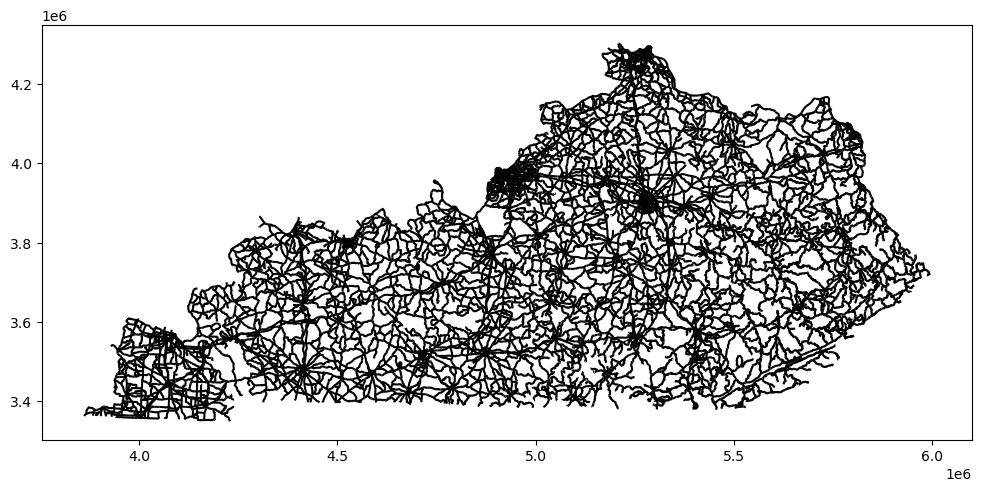

In [22]:
#plt.subplots(1, 1, figsize=(12, 8))
filtered_gdf.plot(color="k", figsize=(12, 10))
plt.show()

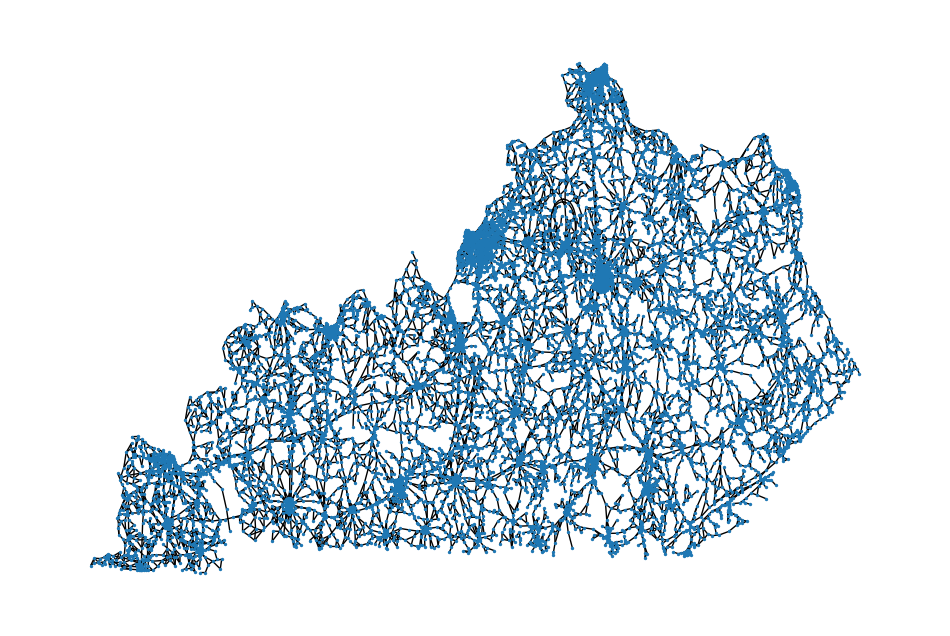

In [23]:
plt.subplots(1, 1, figsize=(12, 8), )
positions = {n: [n[0], n[1]] for n in list(G.nodes)}
nx.draw(G, positions, node_size=2)

## Variable Correlation

In [24]:
varlist = ['TT_BC_Avg','TT_BC_Sum', 'TT_BC_NAvg', 'TT_BC_NSum',
            'Dis_BC_Avg', 'Dis_BC_Sum','Dis_BC_NAv', 'Dis_BC_NSu','AADP',
            'Speed', 'Pop', 'EmployedPo', 'DayPop', 'Workers', 'Residents',
            'Households', 'Families', 'HousingUnits', 'AvgHHIncome', 'MedianHHIncome',
            'PerCapitaIncome', 'MedianHome', 'MedianAge', 'Businesses', 'Employees',
            'Residential', 'Emp_ResPop', 'Area', 'LaneWidth', 'Nlanes', 
            'F_SYSTEM', 'TerrainType','MedianType', 'MedianWidth', 'LeftShoulderWidth', 'RightShoulderWidth', 
            'AccessControl', 'TypeFacility', 'SpeedLimit', 'PopDen','DayPopDen','HouseholdDen',
            'HUDen', 'BusinessDen', 'EmployeeDen','Rural',
            'AADT', 
]




In [25]:
def corr_matrix(df: pd.DataFrame, varlist: list[str]) -> Styler:
    corr_mat = df[varlist].corr(method='pearson')
    corr_mask = np.zeros_like(corr_mat, dtype=bool)
    corr_mask[np.triu_indices_from(corr_mask)] = True
    
    styled_corr = (corr_mat
                     .style
                     .background_gradient(cmap='coolwarm', axis=None, vmin=-1, vmax=1)
                     .highlight_null(color='#f1f1f1')  # Color NaNs grey
                     .format(precision=2))
    return styled_corr

In [26]:
corr_matrix(filtered_gdf, varlist)

,TT_BC_Avg,TT_BC_Sum,TT_BC_NAvg,TT_BC_NSum,Dis_BC_Avg,Dis_BC_Sum,Dis_BC_NAv,Dis_BC_NSu,AADP,Speed,Pop,EmployedPo,DayPop,Workers,Residents,Households,Families,HousingUnits,AvgHHIncome,MedianHHIncome,PerCapitaIncome,MedianHome,MedianAge,Businesses,Employees,Residential,Emp_ResPop,Area,LaneWidth,Nlanes,F_SYSTEM,TerrainType,MedianType,MedianWidth,LeftShoulderWidth,RightShoulderWidth,AccessControl,TypeFacility,SpeedLimit,PopDen,DayPopDen,HouseholdDen,HUDen,BusinessDen,EmployeeDen,Rural,AADT
TT_BC_Avg,1.00,1.00,1.00,1.00,0.40,0.41,0.40,0.41,0.70,0.39,0.36,0.38,0.22,0.17,0.33,0.35,0.40,0.33,0.14,0.14,0.14,0.15,0.02,0.25,0.18,0.36,0.01,0.24,0.17,0.30,-0.30,-0.09,0.36,0.34,0.36,0.22,-0.32,-0.06,0.06,0.01,-0.00,0.01,0.01,-0.00,-0.00,-0.11,0.69
TT_BC_Sum,1.00,1.00,1.00,1.00,0.40,0.41,0.40,0.41,0.70,0.39,0.36,0.38,0.22,0.17,0.33,0.35,0.40,0.32,0.14,0.14,0.14,0.15,0.02,0.24,0.17,0.36,0.01,0.24,0.17,0.29,-0.30,-0.09,0.36,0.34,0.36,0.22,-0.32,-0.05,0.06,0.01,-0.00,0.01,0.00,-0.01,-0.00,-0.11,0.69
TT_BC_NAvg,1.00,1.00,1.00,1.00,0.40,0.41,0.40,0.41,0.70,0.39,0.36,0.38,0.22,0.17,0.33,0.35,0.40,0.33,0.14,0.14,0.14,0.15,0.02,0.25,0.18,0.36,0.01,0.24,0.17,0.30,-0.30,-0.09,0.36,0.34,0.36,0.22,-0.32,-0.06,0.06,0.01,-0.00,0.01,0.01,-0.00,-0.00,-0.11,0.69
TT_BC_NSum,1.00,1.00,1.00,1.00,0.40,0.41,0.40,0.41,0.70,0.39,0.36,0.38,0.22,0.17,0.33,0.35,0.40,0.32,0.14,0.14,0.14,0.15,0.02,0.24,0.17,0.36,0.01,0.24,0.17,0.29,-0.30,-0.09,0.36,0.34,0.36,0.22,-0.32,-0.05,0.06,0.01,-0.00,0.01,0.00,-0.01,-0.00,-0.11,0.69
Dis_BC_Avg,0.40,0.40,0.40,0.40,1.00,0.99,1.00,0.99,0.24,0.05,0.25,0.27,0.15,0.12,0.22,0.25,0.26,0.24,0.22,0.21,0.25,0.27,0.01,0.22,0.13,0.25,0.02,-0.10,0.15,0.18,-0.21,-0.17,0.16,0.11,0.11,0.04,-0.07,-0.06,-0.15,0.21,0.12,0.22,0.21,0.17,0.11,-0.31,0.42
Dis_BC_Sum,0.41,0.41,0.41,0.41,0.99,1.00,0.99,1.00,0.25,0.06,0.24,0.27,0.15,0.12,0.22,0.25,0.26,0.23,0.22,0.22,0.26,0.26,0.01,0.21,0.12,0.24,0.02,-0.10,0.14,0.18,-0.20,-0.16,0.16,0.11,0.11,0.05,-0.07,-0.04,-0.15,0.18,0.09,0.20,0.19,0.13,0.08,-0.30,0.43
Dis_BC_NAv,0.40,0.40,0.40,0.40,1.00,0.99,1.00,0.99,0.24,0.05,0.25,0.27,0.15,0.12,0.22,0.25,0.26,0.24,0.22,0.21,0.25,0.27,0.01,0.22,0.13,0.25,0.02,-0.10,0.15,0.18,-0.21,-0.17,0.16,0.11,0.11,0.04,-0.07,-0.06,-0.15,0.21,0.12,0.22,0.21,0.17,0.11,-0.31,0.42
Dis_BC_NSu,0.41,0.41,0.41,0.41,0.99,1.00,0.99,1.00,0.25,0.06,0.24,0.27,0.15,0.12,0.22,0.25,0.26,0.23,0.22,0.22,0.26,0.26,0.01,0.21,0.12,0.24,0.02,-0.10,0.14,0.18,-0.20,-0.16,0.16,0.11,0.11,0.05,-0.07,-0.04,-0.15,0.18,0.09,0.20,0.19,0.13,0.08,-0.30,0.43
AADP,0.70,0.70,0.70,0.70,0.24,0.25,0.24,0.25,1.00,0.38,0.42,0.44,0.35,0.31,0.40,0.42,0.43,0.41,0.12,0.12,0.14,0.14,0.00,0.36,0.31,0.42,0.02,0.28,0.19,0.42,-0.35,-0.11,0.52,0.42,0.49,0.20,-0.42,-0.07,0.05,0.06,0.05,0.07,0.07,0.05,0.05,-0.14,0.83
Speed,0.39,0.39,0.39,0.39,0.05,0.06,0.05,0.06,0.38,1.00,-0.05,-0.03,-0.04,-0.03,-0.07,-0.06,-0.02,-0.06,0.10,0.12,0.04,0.01,0.08,-0.14,-0.04,-0.05,-0.05,0.56,-0.07,0.14,-0.15,0.11,0.21,0.24,0.24,0.38,-0.27,0.08,0.48,-0.42,-0.27,-0.42,-0.42,-0.38,-0.25,0.36,0.23


In [27]:
filtered_gdf[varlist].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
TT_BC_Avg,12638.0,4.802894e+06,1.353746e+07,0.000000,361828.188322,1.258633e+06,4.106582e+06,2.346321e+08
TT_BC_Sum,12638.0,9.540879e+06,2.700378e+07,0.000000,720463.406972,2.487119e+06,8.064695e+06,4.692642e+08
TT_BC_NAvg,12638.0,4.900819e-05,1.381347e-04,0.000000,0.000004,1.284295e-05,4.190310e-05,2.394159e-03
TT_BC_NSum,12638.0,9.735405e-05,2.755435e-04,0.000000,0.000007,2.537829e-05,8.229123e-05,4.788319e-03
Dis_BC_Avg,12638.0,2.363257e+06,4.556957e+06,0.000000,364420.375163,9.470898e+05,2.346835e+06,6.054115e+07
Dis_BC_Sum,12638.0,4.641366e+06,8.969820e+06,0.000000,723253.243046,1.876613e+06,4.635784e+06,1.210823e+08
Dis_BC_NAv,12638.0,2.411441e-05,4.649868e-05,0.000000,0.000004,9.663997e-06,2.394684e-05,6.177550e-04
Dis_BC_NSu,12638.0,4.735997e-05,9.152704e-05,0.000000,0.000007,1.914875e-05,4.730302e-05,1.235510e-03
AADP,12638.0,7.139845e+01,2.012878e+02,0.000000,11.359954,2.697056e+01,5.992205e+01,3.174193e+03
Speed,12638.0,3.654413e+01,1.183156e+01,8.740486,27.959257,3.547475e+01,4.439511e+01,7.129057e+01


In [28]:
cat_cols = ['TerrainType', 'MedianType', 'AccessControl', 'Rural', 'TypeFacility']
filtered_gdf[cat_cols] = filtered_gdf[cat_cols].astype('category')
print(filtered_gdf[cat_cols].dtypes)

TerrainType      category
MedianType       category
AccessControl    category
Rural            category
TypeFacility     category
dtype: object


## XGBoost

In [30]:
# Remember: don't reset index anymore from here on, otherwise fold indices would change and incorrect folds will be supplied to model

In [29]:
def rmse(preds, dtrain):
    labels = dtrain.get_label()
    return "rmse", mean_squared_error(labels, preds, squared=False)  

def mape(preds, dtrain):
    labels = dtrain.get_label()
    return "mape", np.mean(np.abs((labels - preds) / labels)) * 100  

def mae(preds, dtrain):
    labels = dtrain.get_label()
    return "mae", mean_absolute_error(labels, preds)  

def r2(preds, dtrain):
    labels = dtrain.get_label()
    return "r2", r2_score(labels, preds)  # R^2 Score

In [30]:
# Define the folds. this is to get indices of rows for each fold to be used in xgb.cv algorithm
folds = []
kgrouped = filtered_gdf.groupby('fold')

In [31]:
kgrouped.get_group(6).head()

,OBJECTID,fold,Year,TT_BC_Avg,TT_BC_Sum,TT_BC_NAvg,TT_BC_NSum,Dis_BC_Avg,Dis_BC_Sum,Dis_BC_NAv,Dis_BC_NSu,AADP,Speed,Pop,EmployedPo,DayPop,Workers,Residents,Households,Families,HousingUnits,AvgHHIncome,MedianHHIncome,PerCapitaIncome,MedianHome,MedianAge,Businesses,Employees,Residential,Emp_ResPop,Area,LaneWidth,Nlanes,FC,AreaType,F_SYSTEM,TerrainType,MedianType,MedianWidth,LeftShoulderWidth,RightShoulderWidth,AccessControl,TypeFacility,SpeedLimit,AADT,County,geometry,PopDen,DayPopDen,HouseholdDen,HUDen,BusinessDen,EmployeeDen,Rural
11,5248,6,2017,4.259799e+06,8.519599e+06,4.346651e-05,0.000087,2.216120e+06,4.432240e+06,0.000023,0.000045,110.041785,38.820189,76,35,219,177,42,37,28,43,73081,60634,28263,100000,41.3,21,295,76,388,0.497043,15.0,1.0,1,Rural,1,2.0,1.0,0.0,0.0,0.0,3,1,35.0,10359,Boyd,"LINESTRING (5795929.126 4035788.570, 5795930.3...",152.904412,440.606135,74.440306,86.511707,42.249903,593.510548,1
20,4397,6,2016,1.160859e+07,2.321718e+07,1.184527e-04,0.000237,2.599900e+06,5.199800e+06,0.000027,0.000053,54.764207,40.481943,78,47,660,630,30,38,28,42,59700,40063,23916,100000,43.5,40,500,78,641,2.032821,16.0,1.0,1,Rural,1,2.0,1.0,0.0,0.0,0.0,3,1,35.0,4672,Caldwell,"LINESTRING (4296474.792 3575436.934, 4296489.7...",38.370326,324.671987,18.693236,20.660945,19.677090,245.963626,1
33,1222,6,2016,2.431687e+07,4.863373e+07,2.481266e-04,0.000496,3.799849e+06,7.599698e+06,0.000039,0.000078,107.554852,60.690536,32,13,19,0,19,11,7,13,57995,31741,24712,100000,40.0,0,0,32,0,3.362757,9.0,2.0,7,Rural,1,2.0,1.0,0.0,0.0,0.0,3,1,35.0,6991,Trigg,"LINESTRING (4340711.322 3486824.362, 4340726.7...",9.516001,5.650125,3.271125,3.865875,0.000000,0.000000,1
34,3035,6,2017,6.290510e+06,1.258102e+07,6.418765e-05,0.000128,1.585872e+06,3.171745e+06,0.000016,0.000032,40.246195,38.868232,195,81,313,197,116,84,58,120,54864,37084,21979,96429,40.8,35,415,195,213,1.468466,12.0,2.0,1,Rural,1,1.0,1.0,0.0,0.0,0.0,3,1,35.0,7733,Bath,"LINESTRING (5492928.900 3943717.800, 5492978.8...",132.791617,213.147570,57.202543,81.717918,23.834393,282.607801,1
77,9831,6,2017,8.518605e+04,1.703721e+05,8.692289e-07,0.000002,2.738080e+05,5.476161e+05,0.000003,0.000006,15.980074,28.412356,586,234,492,323,169,68,48,75,85586,68582,22263,177381,29.3,10,673,586,115,3.163483,7.0,2.0,1,Rural,1,2.0,4.0,99.0,5.0,10.0,1,2,70.0,377,Franklin,"LINESTRING (5180785.200 3942890.700, 5180763.6...",185.238840,155.524760,21.495292,23.708043,3.161072,212.740170,1


In [32]:
for key, _ in kgrouped:
    group = kgrouped.get_group(key)
    train_idx = filtered_gdf.index.difference(group.index)
    test_idx = group.index
    folds.append((train_idx.tolist(), test_idx.tolist()))

# Model without Streetlight variable

## feature selection

In [56]:
# List potential features
potential_features = [
            'TT_BC_NAvg',  #'TT_BC_Avg', 'TT_BC_Sum', 'TT_BC_NSum',
            #'Dis_BC_Avg', 'Dis_BC_NAv', # 'Dis_BC_Sum', 'Dis_BC_NSu',
    
            'Pop', 'EmployedPo', 'DayPop', 'Households', 'Families', 'HousingUnits', # 'Workers', 'Residents', 
            'PopDen','DayPopDen','HouseholdDen', 'BusinessDen', 'EmployeeDen',  #'HUDen',
    
            'AvgHHIncome', 'MedianHHIncome', 'PerCapitaIncome',       # 'MedianAge',
            'MedianHome',  'Businesses', 'Residential', #'Emp_ResPop', # 'Employees',
    
            'AADP', 'Speed', 'LaneWidth', 'Nlanes', 'F_SYSTEM', 'TerrainType','MedianType', 'MedianWidth', 'LeftShoulderWidth', 
            'RightShoulderWidth',  'TypeFacility', 'SpeedLimit', 'Rural', #'AccessControl',
]

print(len(potential_features))

31


In [57]:
corr_matrix(filtered_gdf, potential_features)

,TT_BC_NAvg,Pop,EmployedPo,DayPop,Households,Families,HousingUnits,PopDen,DayPopDen,HouseholdDen,BusinessDen,EmployeeDen,AvgHHIncome,MedianHHIncome,PerCapitaIncome,MedianHome,Businesses,Residential,AADP,Speed,LaneWidth,Nlanes,F_SYSTEM,TerrainType,MedianType,MedianWidth,LeftShoulderWidth,RightShoulderWidth,TypeFacility,SpeedLimit,Rural
TT_BC_NAvg,1.00,0.36,0.38,0.22,0.35,0.40,0.33,0.01,-0.00,0.01,-0.00,-0.00,0.14,0.14,0.14,0.15,0.25,0.36,0.70,0.39,0.17,0.30,-0.30,-0.09,0.36,0.34,0.36,0.22,-0.06,0.06,-0.11
Pop,0.36,1.00,0.98,0.74,0.99,0.98,0.98,0.51,0.22,0.51,0.24,0.18,0.07,0.07,0.13,0.13,0.73,1.00,0.42,-0.05,0.24,0.20,-0.25,-0.24,0.24,0.14,0.19,-0.02,-0.10,-0.24,-0.41
EmployedPo,0.38,0.98,1.00,0.73,0.98,0.97,0.97,0.48,0.19,0.49,0.22,0.15,0.12,0.12,0.18,0.16,0.72,0.98,0.44,-0.03,0.22,0.20,-0.25,-0.22,0.24,0.15,0.20,-0.01,-0.08,-0.22,-0.39
DayPop,0.22,0.74,0.73,1.00,0.77,0.66,0.79,0.30,0.40,0.31,0.37,0.39,0.02,-0.00,0.08,0.11,0.92,0.74,0.35,-0.04,0.18,0.19,-0.20,-0.17,0.21,0.10,0.14,-0.01,-0.12,-0.17,-0.29
Households,0.35,0.99,0.98,0.77,1.00,0.96,1.00,0.49,0.22,0.52,0.25,0.18,0.06,0.06,0.14,0.13,0.76,0.99,0.42,-0.06,0.23,0.19,-0.24,-0.23,0.23,0.13,0.18,-0.02,-0.09,-0.24,-0.39
Families,0.40,0.98,0.97,0.66,0.96,1.00,0.95,0.44,0.16,0.45,0.18,0.11,0.11,0.12,0.16,0.14,0.65,0.98,0.43,-0.02,0.23,0.20,-0.25,-0.23,0.24,0.16,0.20,0.00,-0.07,-0.23,-0.40
HousingUnits,0.33,0.98,0.97,0.79,1.00,0.95,1.00,0.49,0.22,0.52,0.26,0.19,0.05,0.04,0.12,0.12,0.78,0.98,0.41,-0.06,0.23,0.19,-0.23,-0.23,0.22,0.12,0.17,-0.03,-0.10,-0.24,-0.38
PopDen,0.01,0.51,0.48,0.30,0.49,0.44,0.49,1.00,0.50,0.93,0.58,0.44,-0.03,-0.04,0.06,0.12,0.36,0.51,0.06,-0.42,0.25,0.07,-0.17,-0.33,0.01,-0.03,-0.02,-0.23,-0.19,-0.48,-0.53
DayPopDen,-0.00,0.22,0.19,0.40,0.22,0.16,0.22,0.50,1.00,0.45,0.84,0.94,-0.04,-0.08,0.02,0.13,0.39,0.22,0.05,-0.27,0.15,0.06,-0.12,-0.21,0.02,-0.01,-0.01,-0.14,-0.22,-0.27,-0.30
HouseholdDen,0.01,0.51,0.49,0.31,0.52,0.45,0.52,0.93,0.45,1.00,0.59,0.40,-0.02,-0.03,0.09,0.14,0.39,0.51,0.07,-0.42,0.25,0.08,-0.17,-0.34,0.01,-0.03,-0.02,-0.24,-0.20,-0.47,-0.53


In [61]:
filtered_gdf[potential_features].dtypes

TT_BC_NAvg             float64
Pop                      int64
EmployedPo               int64
DayPop                   int64
Households               int64
Families                 int64
HousingUnits             int64
PopDen                 float64
DayPopDen              float64
HouseholdDen           float64
BusinessDen            float64
EmployeeDen            float64
AvgHHIncome              int64
MedianHHIncome           int64
PerCapitaIncome          int64
MedianHome               int64
Businesses               int64
Residential              int64
AADP                   float64
Speed                  float64
LaneWidth              float64
Nlanes                 float64
F_SYSTEM                 int64
TerrainType           category
MedianType            category
MedianWidth            float64
LeftShoulderWidth      float64
RightShoulderWidth     float64
TypeFacility          category
SpeedLimit             float64
Rural                 category
dtype: object

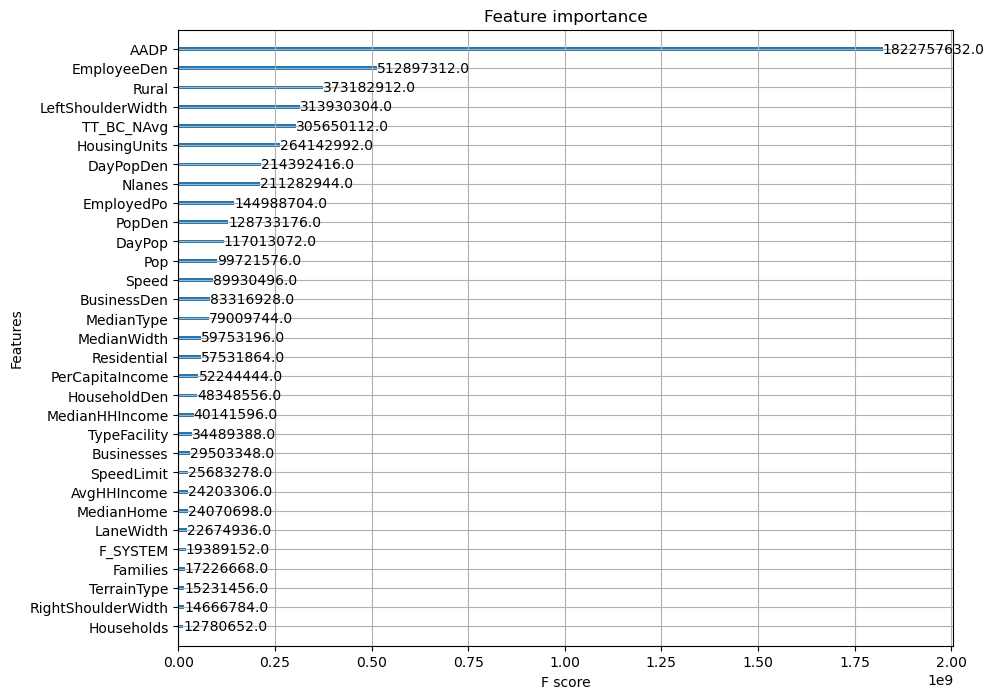

In [58]:
# Check initial xgb model feature importance scores to narrow down potential features

# Define model parameters
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.1,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'gpu_hist', # 'exact', 'gpu_hist'
    'lambda': 2.,  #l2-regularization
    'alpha': 0.11,  #l1-regularization
    'seed': 42
}

dtrain_init = xgb.DMatrix(filtered_gdf[potential_features], label=filtered_gdf['AADT'], enable_categorical=True)
init_model = xgb.train(params, dtrain_init, num_boost_round = 1000)
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(init_model, importance_type = 'gain', ax=ax)
plt.show()

In [62]:
#define base model for variable selection:

def base_model(dtrain, fold_indices=folds):
    # Define base model parameters
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'learning_rate': 0.1,
        'max_depth': 5,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'tree_method': 'exact', # 'exact', 'gpu_hist'
        'lambda': 2.,  #l2-regularization
        'alpha': 0.11,  #l1-regularization
        'seed': 42
    }
    
    return xgb.cv(
            params=params,
            dtrain=dtrain,
            nfold=len(fold_indices),
            folds=fold_indices,
            num_boost_round=2000,
            early_stopping_rounds=30,
            feval=lambda preds, dtrain: [
               rmse(preds, dtrain),
               mape(preds, dtrain),
            ],
            verbose_eval=False,
            as_pandas=True,
            shuffle=False,
        )

In [ ]:
# https://faculty.cc.gatech.edu/~hic/CS7616/Papers/Kumar-Minz-2014.pdf
# https://ieeexplore.ieee.org/document/5895111

### Sequential Forward Feature Selection [Algorithm link](https://rasbt.github.io/mlxtend/user_guide/feature_selection/SequentialFeatureSelector/)

In [63]:
#best 1 variable model, then best 2 variable model by adding to best 1, up to best n-variable model

selected_features = []
available_features = potential_features.copy()

# Store RMSE/MAPE
score_by_feature_number = []
selected_features_rmse = []
selected_features_mape = []

k = len(potential_features) # desired number of features k= len(potential_features) explores all features

# Iterate for the desired number of features
for i in range(k): 
    best_feature = None
    best_rmse = float('inf')  # Start with a high RMSE/MAPE
    best_mape = float('inf')
    
    # Loop through the available features to find the one that minimizes RMSE
    for feature in available_features:
        current_features = selected_features + [feature]
        
        # generate dtrain for current feature being evaluated
        X_current = filtered_gdf[current_features]
        dtrain = xgb.DMatrix(X_current, label=filtered_gdf['AADT'], enable_categorical=True)
        
        # Perform cross-validation using base model defined above
        xgb_results = base_model(dtrain)
        
        # Get mean RMSE for the current feature set
        mean_rmse = xgb_results['test-rmse-mean'].iloc[-1]
        mean_mape = xgb_results['test-mape-mean'].iloc[-1]
        
        # Update best feature and RMSE & MAPE if this feature is better 
        if mean_rmse < best_rmse:
            best_rmse = mean_rmse
            best_mape = mean_mape
            best_feature = feature
    
    # Add the best feature to the selected features
    selected_features.append(best_feature)
    selected_features_rmse.append(best_rmse)
    selected_features_mape.append(best_mape)
    available_features.remove(best_feature)
    score_by_feature_number.append((i + 1, best_feature, best_rmse, best_mape))
    
    # Print progress
    print(f"Feature {i + 1:2d}: {best_feature}, RMSE: {best_rmse:.4f}, MAPE: {best_mape:.2f}")

# Output the final selected features and their corresponding RMSEs
#print("\nSelected features and their RMSE & MAPEs:")
#for feature_info in score_by_feature_number:
#    print(f"Feature {feature_info[0]:2d}: {feature_info[1]}, RMSE: {feature_info[2]:.4f}, MAPE: {feature_info[3]:.2f}")

Feature  1: AADP, RMSE: 7160.0914, MAPE: 96.38
Feature  2: EmployedPo, RMSE: 5645.0507, MAPE: 77.22
Feature  3: BusinessDen, RMSE: 4368.7652, MAPE: 65.42
Feature  4: Speed, RMSE: 3867.3882, MAPE: 61.40
Feature  5: Nlanes, RMSE: 3732.7492, MAPE: 61.38
Feature  6: TT_BC_NAvg, RMSE: 3566.8169, MAPE: 54.25
Feature  7: PerCapitaIncome, RMSE: 3461.7997, MAPE: 53.90
Feature  8: Households, RMSE: 3360.3210, MAPE: 53.21
Feature  9: DayPopDen, RMSE: 3342.2698, MAPE: 52.38
Feature 10: LeftShoulderWidth, RMSE: 3290.4569, MAPE: 51.92
Feature 11: AvgHHIncome, RMSE: 3261.6335, MAPE: 52.53
Feature 12: HousingUnits, RMSE: 3284.6490, MAPE: 51.51
Feature 13: EmployeeDen, RMSE: 3321.6812, MAPE: 51.61
Feature 14: DayPop, RMSE: 3361.2979, MAPE: 51.51
Feature 15: RightShoulderWidth, RMSE: 3369.2523, MAPE: 52.46
Feature 16: Rural, RMSE: 3352.7519, MAPE: 51.51
Feature 17: F_SYSTEM, RMSE: 3270.7948, MAPE: 51.62
Feature 18: TypeFacility, RMSE: 3300.3770, MAPE: 51.24
Feature 19: Businesses, RMSE: 3316.6400, MAPE:

### Sequential Forward Floating Selection [Algorithm paper link](https://www.sciencedirect.com/science/article/pii/0167865594901279/)

In [67]:
sffs_selected_features = []
available_features = potential_features.copy()

# Store RMSE/MAPE and track the current best set
sffs_score_by_feature_number = []


best_rmse = float('inf')
best_mape = float('inf')

k = len(potential_features) # desired number of features

for i in range(k):
    best_feature = None
    
    # Forward step: Add the best feature
    for feature in available_features:
        current_features = sffs_selected_features + [feature]
        
        # Separate features and target for the current subset
        X_current = filtered_gdf[current_features]
        dtrain = xgb.DMatrix(X_current, label=filtered_gdf['AADT'], enable_categorical=True)
        
        # Perform cross-validation
        xgb_results = base_model(dtrain)
        
        # Get mean RMSE and MAPE for the current feature set
        mean_rmse = xgb_results['test-rmse-mean'].iloc[-1]
        mean_mape = xgb_results['test-mape-mean'].iloc[-1]
        
        # Update best feature and metrics if performance improves
        if mean_rmse < best_rmse:
            best_rmse = mean_rmse
            best_mape = mean_mape
            best_feature = feature
    
    # Add the best feature
    if best_feature:
        sffs_selected_features.append(best_feature)
        available_features.remove(best_feature)
        sffs_score_by_feature_number.append((len(sffs_selected_features), best_feature, best_rmse, best_mape))
        print(f"Feature {len(sffs_selected_features)} added: {best_feature}, RMSE: {best_rmse:.4f}, MAPE: {best_mape:.2f}")
    
    # Floating step: Check if removing any previously selected feature improves performance
    floating_feature = None
    for feature in sffs_selected_features[:-1]:  # Check excludes the last added feature - current feature
        temp_features = [f for f in sffs_selected_features if f != feature]
        
        X_temp = filtered_gdf[temp_features]
        dtrain_temp = xgb.DMatrix(X_temp, label=filtered_gdf['AADT'], enable_categorical=True)
        
        # Perform cross-validation for this reduced set
        xgb_results_temp = base_model(dtrain_temp)
        
        # Get mean RMSE and MAPE for the reduced feature set
        mean_rmse_temp = xgb_results_temp['test-rmse-mean'].iloc[-1]
        mean_mape_temp = xgb_results_temp['test-mape-mean'].iloc[-1]
        
        # Remove the feature if performance improves
        if mean_rmse_temp < best_rmse:
            best_rmse = mean_rmse_temp
            best_mape = mean_mape_temp
            floating_feature = feature
            print(f"Removing feature {feature} improved RMSE: {best_rmse:.4f}")
    
    if floating_feature:
        sffs_selected_features.remove(floating_feature)
        sffs_score_by_feature_number = [item for item in sffs_score_by_feature_number if item[1] != floating_feature]
        #sffs_score_by_feature_number = [(i + 1, *item[1:]) for i, item in enumerate(sffs_score_by_feature_number)] # for renumbering. decided not to cos I wanna know where features were removed
        sffs_score_by_feature_number[-1] = (sffs_score_by_feature_number[-1][0], sffs_score_by_feature_number[-1][1], best_rmse, best_mape)

Feature 1 added: AADP, RMSE: 7160.0914, MAPE: 96.38
Feature 2 added: EmployedPo, RMSE: 5645.0507, MAPE: 77.22
Feature 3 added: BusinessDen, RMSE: 4368.7652, MAPE: 65.42
Feature 4 added: Speed, RMSE: 3867.3882, MAPE: 61.40
Feature 5 added: Nlanes, RMSE: 3732.7492, MAPE: 61.38
Feature 6 added: TT_BC_NAvg, RMSE: 3566.8169, MAPE: 54.25
Feature 7 added: PerCapitaIncome, RMSE: 3461.7997, MAPE: 53.90
Feature 8 added: Households, RMSE: 3360.3210, MAPE: 53.21
Feature 9 added: DayPopDen, RMSE: 3342.2698, MAPE: 52.38
Feature 10 added: LeftShoulderWidth, RMSE: 3290.4569, MAPE: 51.92
Feature 11 added: AvgHHIncome, RMSE: 3261.6335, MAPE: 52.53


## Modeling with Selected Variables

In [ ]:
feature_list = ['AADP', 'EmployedPo', 'BusinessDen', 'Speed', 'Nlanes', 'TT_BC_NAvg', 'PerCapitaIncome', 'Households',  'DayPopDen','LeftShoulderWidth', 'AvgHHIncome',  ]#selected_features[:17]
print(feature_list)

target = ['AADT']

['AADP', 'EmployedPo', 'BusinessDen', 'Speed', 'Nlanes', 'TT_BC_NAvg', 'PerCapitaIncome', 'Households', 'LeftShoulderWidth', 'AvgHHIncome', 'HousingUnits', 'EmployeeDen', 'DayPop', 'RightShoulderWidth', 'Rural', 'F_SYSTEM']


In [34]:
# Separate features and target
X = filtered_gdf[feature_list]
y = filtered_gdf[target]

In [35]:
display(X.head())
display(y.head())

,AADP,EmployedPo,BusinessDen,Speed,Nlanes,TT_BC_NAvg,PerCapitaIncome,Households,LeftShoulderWidth,AvgHHIncome,HousingUnits,EmployeeDen,DayPop,RightShoulderWidth,Rural,F_SYSTEM
0,115.404530,82,12.724046,39.198492,1.0,0.000138,29166,70,0.0,65153,86,124.155843,468,0.0,1,1
1,20.053668,48,0.000000,47.263929,1.0,0.000035,28997,62,0.0,63792,74,0.000000,78,0.0,1,1
2,19.685706,16,4.894176,34.134172,1.0,0.000014,27268,10,0.0,76755,13,63.624285,131,0.0,1,1
3,25.776664,72,0.000000,43.031010,1.0,0.000008,35196,60,0.0,99779,70,0.000000,86,0.0,1,1
4,19.155028,126,7.519411,31.491711,1.0,0.000038,39663,127,0.0,108730,132,35.827781,274,0.0,1,1


,AADT
0,8138
1,1029
2,362
3,566
4,929


In [38]:
# Convert data with chosen variables to DMatrix 

dtrain = xgb.DMatrix(X, label=y, enable_categorical=True)

In [174]:
# Define model parameters
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.1,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'exact', # 'exact', 'gpu_hist'
    'lambda': 2.,  #l2-regularization
    'alpha': 0.11,  #l1-regularization
    'seed': 42
}

# Perform cross-validation with predefined folds
xgb_results = xgb.cv(
    params=params,
    dtrain=dtrain,
    nfold = len(folds),
    folds=folds,
    num_boost_round=5000,
    early_stopping_rounds=50,
    
   feval=lambda preds, dtrain: [
        rmse(preds, dtrain),
        mape(preds, dtrain),
        mae(preds, dtrain),
        #r2(preds, dtrain),
    ],
     
    verbose_eval=False,
    as_pandas=True,
    shuffle = False, # whether to Shuffle data before creating folds. already using predefined folds so current thinking is not to shuffle. Will experiment how that affects results later.
    
)

#results for each boosting round.
xgb_results

,train-rmse-mean,train-rmse-std,test-rmse-mean,test-rmse-std,train-mape-mean,train-mape-std,train-mae-mean,train-mae-std,test-mape-mean,test-mape-std,test-mae-mean,test-mae-std
0,11110.190474,133.698842,11127.214658,523.772652,755.815896,6.057434,5372.314697,60.631899,755.946159,32.259707,5368.005453,114.872792
1,11110.190104,133.698727,11127.214843,523.772783,688.489683,3.958536,4929.963705,27.281003,688.351607,28.042801,4933.798177,134.380565
2,10237.651473,90.391205,10314.566995,523.170073,629.825147,4.307883,4541.694417,35.655109,630.020714,26.506372,4554.854981,115.433582
3,10237.651367,90.391373,10314.567220,523.170162,575.401958,5.905029,4193.897705,54.327828,575.775409,23.859968,4216.015788,108.388243
4,9456.333899,81.582491,9586.531851,485.465865,525.310056,5.388395,3874.953898,49.065984,526.083613,21.195502,3902.568685,122.314550
...,...,...,...,...,...,...,...,...,...,...,...,...
244,1758.576336,35.451907,3383.190943,331.039693,43.178245,0.457234,848.098368,13.963121,51.805315,7.284902,1431.211243,77.958767
245,1758.576355,35.451894,3383.190959,331.039705,43.143156,0.453288,846.798757,13.719865,51.801643,7.346785,1431.085856,78.169230
246,1754.495330,34.204172,3384.463404,331.568374,43.144801,0.473373,845.455119,13.844453,51.784424,7.320420,1431.292725,77.740738
247,1754.495361,34.204175,3384.463419,331.568327,43.103854,0.453703,844.205587,13.641122,51.786392,7.293904,1431.093424,77.774862


### Hyperparameter Optimization

In [ ]:
#FFA
# https://www.sciencedirect.com/science/article/abs/pii/S1568494617303721

In [131]:
def objective_function(solution):
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'learning_rate': solution[0],
        'max_depth': int(solution[1]),  # XGBoost requires max_depth as an integer
        'subsample': solution[2],
        'colsample_bytree': solution[3],
        'lambda': solution[4],
        'alpha': solution[5],
        'tree_method': 'exact',  # 'gpu_hist'
        'seed': 42
    }
    
    # Ensure num_boost_round is an integer
    num_boost_round = int(solution[6])

    # Perform cross-validation
    xgb_results = xgb.cv(
        params=params,
        dtrain=dtrain,
        nfold=len(folds),
        folds=folds,
        num_boost_round=num_boost_round,
        early_stopping_rounds=50,
        feval=lambda preds, dtrain: [mape(preds, dtrain)],  
        verbose_eval=False,
        as_pandas=True,
        shuffle=False
    )

    # Return the mean MAPE of the last boosting round
    return xgb_results['test-mape-mean'].iloc[-1]

In [132]:
search_space = [
        FloatVar(lb=0.01, ub=0.3, name="learning_rate"),  # learning rate (float)
        IntegerVar(lb=3, ub=10, name="max_depth"),  # max depth (integer)
        FloatVar(lb=0.5, ub=1.0, name="subsample"),  # subsample ratio (float)
        FloatVar(lb=0.5, ub=1.0, name="colsample_bytree"),  # colsample ratio (float)
        FloatVar(lb=0.0, ub=10.0, name="lambda"),  # L2 regularization (float)
        FloatVar(lb=0.0, ub=10.0, name="alpha"),  # L1 regularization (float)
        IntegerVar(lb=100, ub=5000, name="num_boost_round")  # boosting rounds (integer)
    ]

In [153]:
ffproblem = {
    "obj_func": objective_function,
    "minmax": "min",  # Minimize MAPE
    "bounds": search_space,
    "verbose": True
}

ffmodel = OriginalFFA(epoch = 50, pop_size=20)  #50 20
g_best = ffmodel.solve(ffproblem)

2025/01/28 01:12:32 PM, INFO, mealpy.swarm_based.FFA.OriginalFFA: Solving single objective optimization problem.
2025/01/28 02:46:14 PM, INFO, mealpy.swarm_based.FFA.OriginalFFA: >>>Problem: P, Epoch: 1, Current best: 49.52974233333333, Global best: 49.52974233333333, Runtime: 5279.17775 seconds
2025/01/28 04:26:13 PM, INFO, mealpy.swarm_based.FFA.OriginalFFA: >>>Problem: P, Epoch: 2, Current best: 49.50350233333334, Global best: 49.50350233333334, Runtime: 5999.81709 seconds
2025/01/28 05:58:58 PM, INFO, mealpy.swarm_based.FFA.OriginalFFA: >>>Problem: P, Epoch: 3, Current best: 49.50350233333334, Global best: 49.50350233333334, Runtime: 5564.16158 seconds
2025/01/28 07:35:16 PM, INFO, mealpy.swarm_based.FFA.OriginalFFA: >>>Problem: P, Epoch: 4, Current best: 49.49747066666666, Global best: 49.49747066666666, Runtime: 5778.40167 seconds
2025/01/28 09:15:12 PM, INFO, mealpy.swarm_based.FFA.OriginalFFA: >>>Problem: P, Epoch: 5, Current best: 49.49747066666666, Global best: 49.49747066666

In [154]:
# Print the best hyperparameters and MAPE
print("Best Solution:", g_best.solution)
print("Best Fitness (MAPE):", g_best.target.fitness)

Best Solution: [7.89894116e-02 8.00000000e+00 9.26789151e-01 9.88511667e-01
 8.92975842e+00 2.04228544e+00 3.94100000e+03]
Best Fitness (MAPE): 49.309298333333324


In [161]:
# Train the final model with optimized parameters
best_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': g_best.solution[0],
    'max_depth': int(g_best.solution[1]),
    'subsample': g_best.solution[2],
    'colsample_bytree': g_best.solution[3],
    'lambda': g_best.solution[4],
    'alpha': g_best.solution[5],
    'tree_method': 'gpu_hist',
    'seed': 42
}

# Ensure num_boost_round is an integer for the final training
final_num_boost_round = int(g_best.solution[6])

# Final training
final_model = xgb.train(
    params=best_params,
    dtrain=dtrain,
    num_boost_round=final_num_boost_round
)

In [162]:
joblib.dump(final_model, 'AADT_model_without_Streetlight_data.joblib')

['AADT_model_without_Streetlight_data.joblib']